<a href="https://colab.research.google.com/github/canunz/EV3_outfits/blob/main/weatherAUS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predicción de Lluvia en Australia — weatherAUS
**BIY7121 Minería de Datos — DuocUC**  
**Integrantes:** Fanny Araujo, Catalina Núñez  
**Etapa 2:** Implementación y Análisis de Resultados

## Paso 1 — Carga y Preprocesamiento

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, roc_curve, auc
)
from imblearn.over_sampling import SMOTE

In [4]:
# Cargamos el dataset
df = pd.read_csv('weatherAUS.csv', on_bad_lines='skip', engine='python')
print(f'Filas: {df.shape[0]:,} | Columnas: {df.shape[1]}')
df.head()

Filas: 73,987 | Columnas: 24


,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RISK_MM,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,0.0,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,0.0,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,0.0,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,1.0,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,0.2,No


In [5]:
# RISK_MM tiene la lluvia del día siguiente — usarla sería trampa (data leakage)
# Date y Location tampoco sirven como predictores
df = df.drop(columns=['RISK_MM', 'Date', 'Location'])
print('Columnas que quedan:', df.shape[1])

Columnas que quedan: 21


In [6]:
# Revisamos cuántos valores faltan por columna
nulos = df.isnull().sum()
pct = (nulos / len(df) * 100).round(2)
resumen = pd.DataFrame({'Nulos': nulos, '% del total': pct})
resumen[resumen['Nulos'] > 0].sort_values('Nulos', ascending=False)

,Nulos,% del total
Sunshine,44217,59.76
Evaporation,37679,50.93
Cloud3pm,29527,39.91
Cloud9am,28569,38.61
Pressure9am,9698,13.11
Pressure3pm,9647,13.04
WindDir9am,6564,8.87
WindGustDir,5503,7.44
WindGustSpeed,5496,7.43
WindDir3pm,2517,3.40


In [7]:
# Imputamos las variables numéricas con la mediana
num_cols = df.select_dtypes(include='number').columns.tolist()
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Las variables de texto las rellenamos con el valor más frecuente
cat_cols = ['WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday']
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print(f'Nulos restantes: {df.isnull().sum().sum()}')

Nulos restantes: 1


In [8]:
# Revisamos outliers con el método IQR en las variables con más valores extremos
vars_out = ['Rainfall', 'WindGustSpeed', 'Evaporation']
for col in vars_out:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lim_sup = Q3 + 1.5 * IQR
    n_out = (df[col] > lim_sup).sum()
    print(f'{col}: {n_out} outliers sobre {lim_sup:.1f}')

# Para Rainfall usamos Winsorizing al percentil 99
# En el norte de Australia las lluvias muy intensas son normales,
# así que no las eliminamos, solo las limitamos
p99 = df['Rainfall'].quantile(0.99)
df['Rainfall'] = df['Rainfall'].clip(upper=p99)
print(f'\nRainfall limitada al percentil 99: {p99:.1f} mm')

Rainfall: 14607 outliers sobre 1.5
WindGustSpeed: 1876 outliers sobre 73.5
Evaporation: 18142 outliers sobre 4.2

Rainfall limitada al percentil 99: 37.4 mm


## Paso 2 — Transformación de Variables

In [9]:
# RainToday y RainTomorrow pasan a 0 y 1
df['RainToday'] = (df['RainToday'] == 'Yes').astype(int)
df['RainTomorrow'] = (df['RainTomorrow'] == 'Yes').astype(int)

# Las direcciones del viento se codifican con One-Hot Encoding
# No tienen un orden, así que no se pueden convertir directo a número
df = pd.get_dummies(df, columns=['WindGustDir', 'WindDir9am', 'WindDir3pm'], drop_first=True)

# Convertimos las columnas booleanas que generó get_dummies a enteros
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

print(f'Total columnas después de codificar: {df.shape[1]}')

Total columnas después de codificar: 63


In [10]:
# Separamos X (predictores) e y (objetivo)
X = df.drop(columns=['RainTomorrow'])
y = df['RainTomorrow']

# División 70% entrenamiento / 30% prueba
# stratify=y para mantener la proporción de clases en ambos sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
print(f'Train: {X_train.shape[0]:,} filas | Test: {X_test.shape[0]:,} filas')

Train: 51,790 filas | Test: 22,197 filas


In [11]:
# StandardScaler para dejar todas las variables en la misma escala
# Importante: se ajusta SOLO con el train para no contaminar el test
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
print('Escalado aplicado correctamente')

Escalado aplicado correctamente


In [12]:
# El dataset tiene muchos más días sin lluvia que con lluvia
# Si entrenamos así, el modelo aprende a predecir siempre 'no llueve'
# SMOTE genera ejemplos sintéticos de días lluviosos para equilibrar
# Se aplica SOLO sobre el set de entrenamiento
print('Distribución ANTES de SMOTE:')
print(pd.Series(y_train).value_counts())

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_sc, y_train)

print('\nDistribución DESPUÉS de SMOTE:')
print(pd.Series(y_train_sm).value_counts())

Distribución ANTES de SMOTE:
RainTomorrow
0    40344
1    11446
Name: count, dtype: int64

Distribución DESPUÉS de SMOTE:
RainTomorrow
0    40344
1    40344
Name: count, dtype: int64


## Paso 3 — Modelado: 3 Modelos Supervisados + 1 No Supervisado

### Modelo 1 — Regresión Logística
El más simple de los tres. Calcula la probabilidad de que llueva mañana. Es fácil de interpretar porque los coeficientes muestran qué variables pesan más.

Accuracy: 0.7857 | F1-Score: 0.6093
              precision    recall  f1-score   support

   No llueve       0.92      0.79      0.85     17292
      Llueve       0.51      0.76      0.61      4905

    accuracy                           0.79     22197
   macro avg       0.72      0.78      0.73     22197
weighted avg       0.83      0.79      0.80     22197



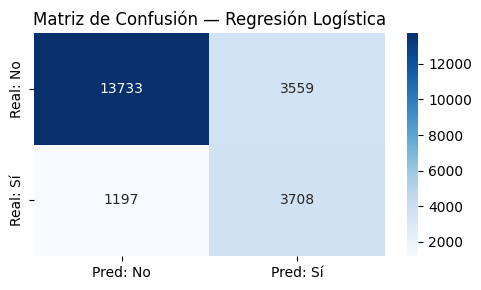

In [13]:
lr = LogisticRegression(max_iter=1000, C=0.5, random_state=42)
lr.fit(X_train_sm, y_train_sm)
lr_pred  = lr.predict(X_test_sc)
lr_proba = lr.predict_proba(X_test_sc)[:, 1]

lr_acc = accuracy_score(y_test, lr_pred)
lr_f1  = f1_score(y_test, lr_pred)
print(f"Accuracy: {lr_acc:.4f} | F1-Score: {lr_f1:.4f}")
print(classification_report(y_test, lr_pred, target_names=["No llueve", "Llueve"]))

# Matriz de confusión
cm_lr = confusion_matrix(y_test, lr_pred)
plt.figure(figsize=(5, 3))
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pred: No", "Pred: Sí"],
            yticklabels=["Real: No", "Real: Sí"])
plt.title("Matriz de Confusión — Regresión Logística")
plt.tight_layout()
plt.show()

### Modelo 2 — SVM
Busca el hiperplano que mejor separa los días con lluvia de los que no. Con kernel RBF puede capturar relaciones no lineales. Necesita datos escalados.

Accuracy: 0.8434 | F1-Score: 0.5522
              precision    recall  f1-score   support

   No llueve       0.86      0.96      0.91     17292
      Llueve       0.75      0.44      0.55      4905

    accuracy                           0.84     22197
   macro avg       0.80      0.70      0.73     22197
weighted avg       0.83      0.84      0.83     22197



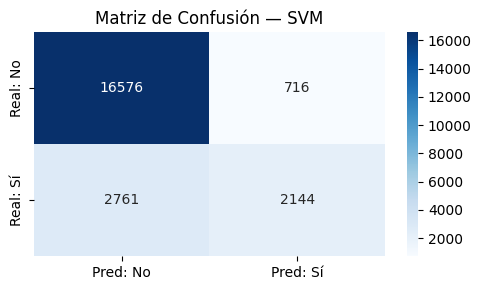

In [14]:
# SVM es lento con datasets muy grandes
# Usamos una muestra del entrenamiento para que corra en tiempo razonable
svm = SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42, probability=True)
svm.fit(X_train_sm[:15000], y_train_sm[:15000])
svm_pred  = svm.predict(X_test_sc)
svm_proba = svm.predict_proba(X_test_sc)[:, 1]

svm_acc = accuracy_score(y_test, svm_pred)
svm_f1  = f1_score(y_test, svm_pred)
print(f"Accuracy: {svm_acc:.4f} | F1-Score: {svm_f1:.4f}")
print(classification_report(y_test, svm_pred, target_names=["No llueve", "Llueve"]))

# Matriz de confusión
cm_svm = confusion_matrix(y_test, svm_pred)
plt.figure(figsize=(5, 3))
sns.heatmap(cm_svm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pred: No", "Pred: Sí"],
            yticklabels=["Real: No", "Real: Sí"])
plt.title("Matriz de Confusión — SVM")
plt.tight_layout()
plt.show()

### Modelo 3 — Árbol de Decisión
Divide los datos con reglas del tipo 'si la humedad es mayor a X, entonces...'. Es fácil de leer y muestra cuáles variables usó más para decidir.

Accuracy: 0.7779 | F1-Score: 0.5527
              precision    recall  f1-score   support

   No llueve       0.88      0.82      0.85     17292
      Llueve       0.50      0.62      0.55      4905

    accuracy                           0.78     22197
   macro avg       0.69      0.72      0.70     22197
weighted avg       0.80      0.78      0.79     22197



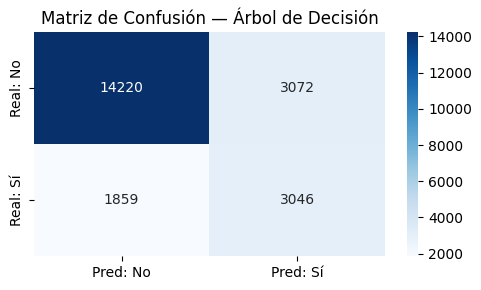

In [15]:
# max_depth=5 para evitar sobreajuste
tree = DecisionTreeClassifier(max_depth=5, criterion="entropy", random_state=42)
tree.fit(X_train_sm, y_train_sm)
tree_pred  = tree.predict(X_test_sc)
tree_proba = tree.predict_proba(X_test_sc)[:, 1]

tree_acc = accuracy_score(y_test, tree_pred)
tree_f1  = f1_score(y_test, tree_pred)
print(f"Accuracy: {tree_acc:.4f} | F1-Score: {tree_f1:.4f}")
print(classification_report(y_test, tree_pred, target_names=["No llueve", "Llueve"]))

# Matriz de confusión
cm_tree = confusion_matrix(y_test, tree_pred)
plt.figure(figsize=(5, 3))
sns.heatmap(cm_tree, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pred: No", "Pred: Sí"],
            yticklabels=["Real: No", "Real: Sí"])
plt.title("Matriz de Confusión — Árbol de Decisión")
plt.tight_layout()
plt.show()

## Paso 4 — Evaluación: Métricas de Rendimiento

In [16]:
# Tabla comparativa de los tres modelos
resultados = pd.DataFrame({
    'Modelo'  : ['Regresión Logística', 'SVM', 'Árbol de Decisión'],
    'Accuracy': [lr_acc, svm_acc, tree_acc],
    'F1-Score': [lr_f1,  svm_f1,  tree_f1]
})
print(resultados.to_string(index=False))

             Modelo  Accuracy  F1-Score
Regresión Logística  0.785737  0.609267
                SVM  0.843357  0.552222
  Árbol de Decisión  0.777853  0.552663


## Paso 5 — Modelos Supervisados: Comparación de Accuracy y Matrices de Confusión

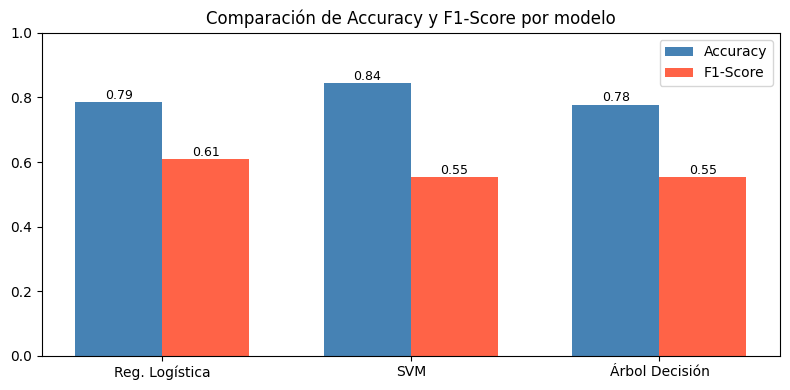

In [17]:
# Gráfico comparativo de Accuracy y F1-Score
x = np.arange(3)
w = 0.35
fig, ax = plt.subplots(figsize=(8, 4))
b1 = ax.bar(x - w/2, resultados['Accuracy'], w, label='Accuracy', color='steelblue')
b2 = ax.bar(x + w/2, resultados['F1-Score'], w, label='F1-Score',  color='tomato')
ax.set_xticks(x)
ax.set_xticklabels(['Reg. Logística', 'SVM', 'Árbol Decisión'])
ax.set_ylim(0, 1)
ax.legend()
ax.set_title('Comparación de Accuracy y F1-Score por modelo')
for b in list(b1) + list(b2):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.01,
            f'{b.get_height():.2f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

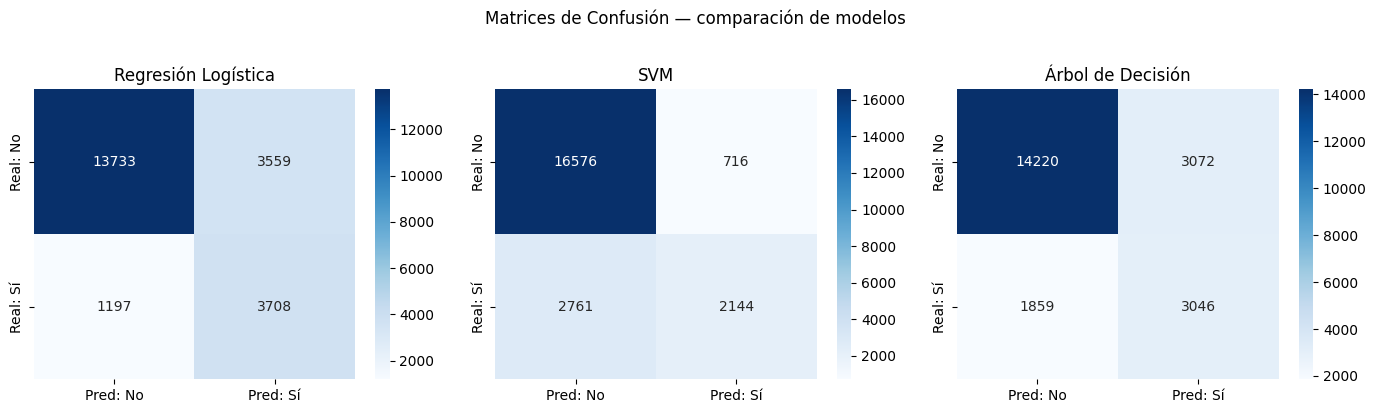

In [18]:
# Matrices de confusión de los tres modelos juntas para comparar
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
modelos_info = [
    ('Regresión Logística', lr_pred),
    ('SVM',                 svm_pred),
    ('Árbol de Decisión',   tree_pred)
]
for ax, (nombre, pred) in zip(axes, modelos_info):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Pred: No', 'Pred: Sí'],
                yticklabels=['Real: No', 'Real: Sí'])
    ax.set_title(nombre)
plt.suptitle('Matrices de Confusión — comparación de modelos', y=1.02)
plt.tight_layout()
plt.show()

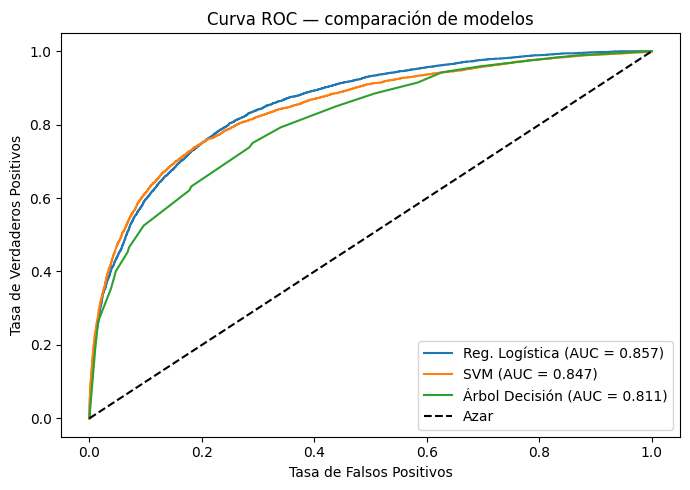

In [19]:
# Curva ROC — muestra qué tan bien separa cada modelo los días con y sin lluvia
# Un AUC más cercano a 1 es mejor
fig, ax = plt.subplots(figsize=(7, 5))
for nombre, proba in [('Reg. Logística', lr_proba),
                       ('SVM',            svm_proba),
                       ('Árbol Decisión', tree_proba)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f'{nombre} (AUC = {roc_auc:.3f})')

ax.plot([0,1],[0,1],'k--', label='Azar')
ax.set_xlabel('Tasa de Falsos Positivos')
ax.set_ylabel('Tasa de Verdaderos Positivos')
ax.set_title('Curva ROC — comparación de modelos')
ax.legend()
plt.tight_layout()
plt.show()

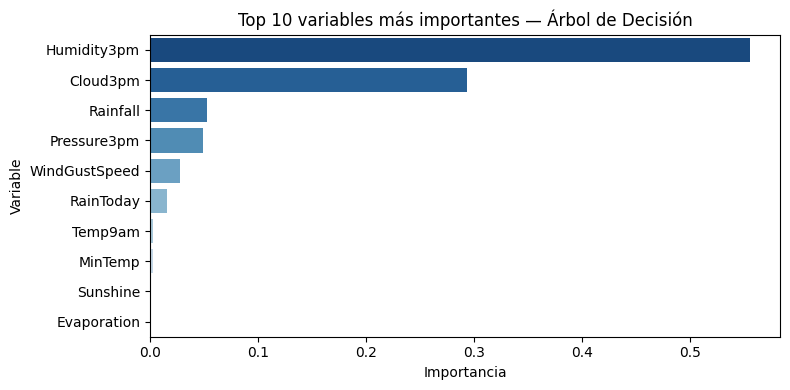

     Variable  Importancia
  Humidity3pm     0.555496
     Cloud3pm     0.293321
     Rainfall     0.052840
  Pressure3pm     0.049084
WindGustSpeed     0.027464
    RainToday     0.016107
      Temp9am     0.002856
      MinTemp     0.002832
     Sunshine     0.000000
  Evaporation     0.000000


In [20]:
# Variables más importantes según el Árbol de Decisión
importancias = pd.DataFrame({
    'Variable'   : X.columns,
    'Importancia': tree.feature_importances_
}).sort_values('Importancia', ascending=False).head(10)

plt.figure(figsize=(8, 4))
sns.barplot(data=importancias, x='Importancia', y='Variable', palette='Blues_r')
plt.title('Top 10 variables más importantes — Árbol de Decisión')
plt.tight_layout()
plt.show()
print(importancias.to_string(index=False))

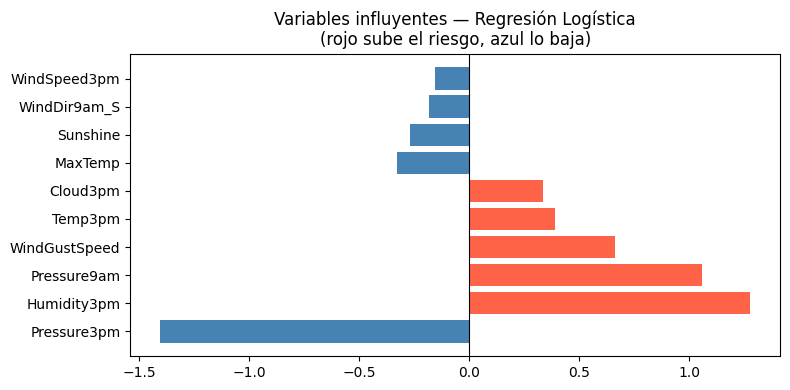

In [21]:
# Coeficientes de la Regresión Logística
# Positivo = sube el riesgo de lluvia / Negativo = lo baja
coefs = pd.DataFrame({
    'Variable'   : X.columns,
    'Coeficiente': lr.coef_[0]
}).sort_values('Coeficiente', key=abs, ascending=False).head(10)

colores = ['tomato' if c > 0 else 'steelblue' for c in coefs['Coeficiente']]
plt.figure(figsize=(8, 4))
plt.barh(coefs['Variable'], coefs['Coeficiente'], color=colores)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Variables influyentes — Regresión Logística\n(rojo sube el riesgo, azul lo baja)')
plt.tight_layout()
plt.show()

### Análisis — Modelos Supervisados

El SVM tiene el mejor accuracy pero la Regresión Logística tiene mejor F1-Score, lo que significa que detecta mejor los días en que sí va a llover. Para este problema eso importa más que el accuracy general, porque no detectar un día lluvioso tiene más consecuencias que una falsa alarma.

El Árbol de Decisión confirma que Humidity3pm y la presión atmosférica son las variables que más pesan. Eso coincide con lo que planteamos en las hipótesis.

## Paso 6 — Modelo No Supervisado: K-Means y Características de cada Cluster

In [22]:
# Variables que se usan para agrupar los días
# Son las más representativas del clima diario
cluster_cols = ['MinTemp', 'MaxTemp', 'Rainfall', 'Humidity9am', 'Humidity3pm',
                'Pressure9am', 'Pressure3pm', 'Temp9am', 'Temp3pm', 'Sunshine', 'Cloud3pm']

X_cluster = df[cluster_cols].copy()
scaler_km = StandardScaler()
X_cluster_sc = scaler_km.fit_transform(X_cluster)

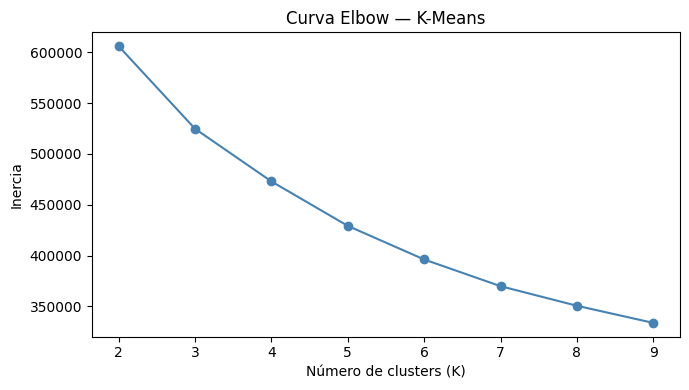

In [23]:
# Curva Elbow para encontrar el número óptimo de clusters
inercias = []
rango_k = range(2, 10)
for k in rango_k:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster_sc)
    inercias.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(rango_k, inercias, marker='o', color='steelblue')
plt.xlabel('Número de clusters (K)')
plt.ylabel('Inercia')
plt.title('Curva Elbow — K-Means')
plt.tight_layout()
plt.show()

In [24]:
# Con K=4 la curva empieza a aplanarse — elegimos 4 grupos
km_final = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster'] = km_final.fit_predict(X_cluster_sc)

print('Días por cluster:')
print(df['Cluster'].value_counts().sort_index())

Días por cluster:
Cluster
0    17928
1    24658
2    16204
3    15197
Name: count, dtype: int64


In [25]:
# Perfil de cada cluster — medias de las variables climáticas
perfil = df.groupby('Cluster')[cluster_cols + ['RainTomorrow']].mean().round(2)
perfil['% lluvia mañana'] = (perfil['RainTomorrow'] * 100).round(1)
perfil = perfil.drop(columns=['RainTomorrow'])
perfil

,MinTemp,MaxTemp,Rainfall,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Temp9am,Temp3pm,Sunshine,Cloud3pm,% lluvia mañana
Cluster,,,,,,,,,,,,
0,4.36,14.72,1.27,83.57,61.16,1023.06,1020.80,8.53,13.71,7.32,5.35,21.0
1,10.42,22.30,0.50,65.16,45.06,1020.27,1017.73,15.65,21.02,8.70,3.93,9.0
2,16.70,31.30,0.48,57.27,34.76,1014.04,1011.17,22.44,29.45,9.05,4.13,13.0
3,14.89,21.37,7.26,81.01,71.61,1013.92,1012.25,17.48,19.51,5.86,6.36,53.0


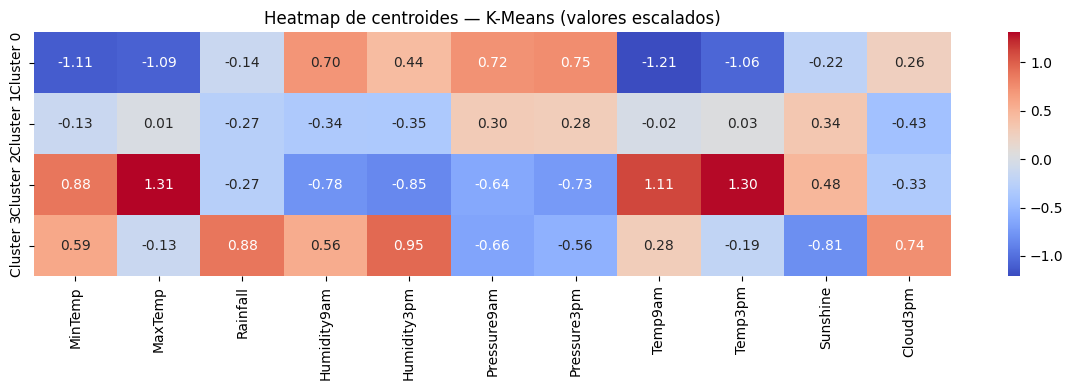

In [26]:
# Heatmap de los centroides — muestra cómo se diferencia cada cluster
centroides = pd.DataFrame(km_final.cluster_centers_, columns=cluster_cols)

plt.figure(figsize=(12, 4))
sns.heatmap(centroides, annot=True, fmt='.2f', cmap='coolwarm',
            yticklabels=[f'Cluster {i}' for i in range(4)])
plt.title('Heatmap de centroides — K-Means (valores escalados)')
plt.tight_layout()
plt.show()

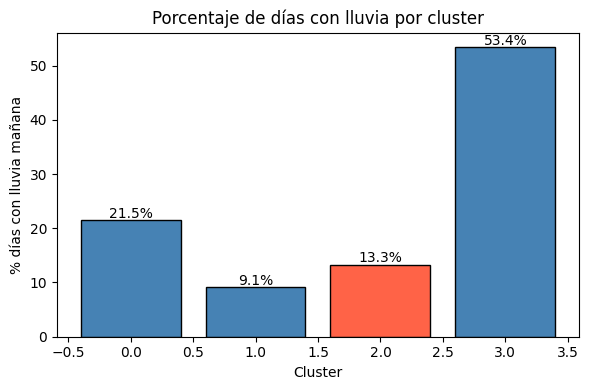

In [27]:
# Porcentaje de lluvia por cluster
lluvia_cluster = df.groupby('Cluster')['RainTomorrow'].mean() * 100

plt.figure(figsize=(6, 4))
bars = plt.bar(lluvia_cluster.index, lluvia_cluster.values,
               color=['steelblue','steelblue','tomato','steelblue'], edgecolor='black')
plt.title('Porcentaje de días con lluvia por cluster')
plt.ylabel('% días con lluvia mañana')
plt.xlabel('Cluster')
for bar, val in zip(bars, lluvia_cluster.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

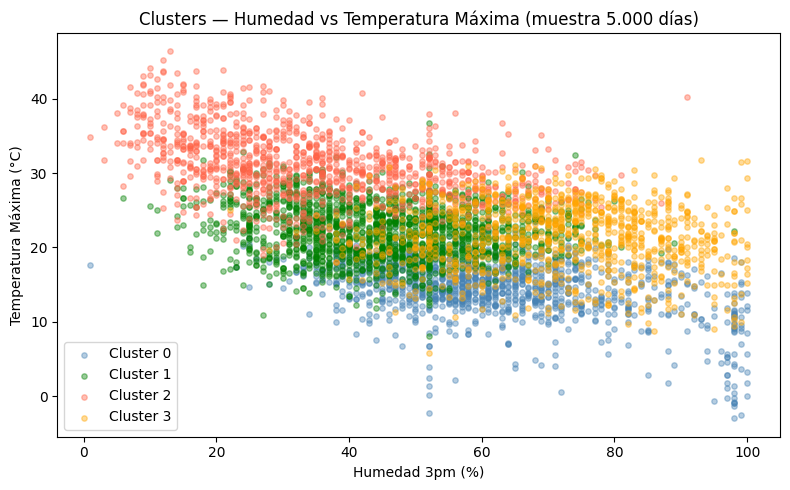

In [28]:
# Scatter — humedad vs temperatura coloreado por cluster
sample = df.sample(5000, random_state=42)
colores_c = {0:'steelblue', 1:'green', 2:'tomato', 3:'orange'}

plt.figure(figsize=(8, 5))
for c in sorted(sample['Cluster'].unique()):
    sub = sample[sample['Cluster'] == c]
    plt.scatter(sub['Humidity3pm'], sub['MaxTemp'],
                c=colores_c[c], alpha=0.4, s=15, label=f'Cluster {c}')
plt.xlabel('Humedad 3pm (%)')
plt.ylabel('Temperatura Máxima (°C)')
plt.title('Clusters — Humedad vs Temperatura Máxima (muestra 5.000 días)')
plt.legend()
plt.tight_layout()
plt.show()

### Características de cada Cluster

Características de cada Cluster

+ Cluster 0 — Días fríos y húmedos: temperatura mínima baja (4°C en promedio), humedad alta en la mañana (83%) y presión atmosférica alta. El 21% de estos días tiene lluvia al día siguiente. Corresponde a días de invierno en zonas del sur del país.

+ Cluster 1 — Días templados y secos: temperatura máxima alrededor de 22°C y humedad moderada (45% en la tarde). Solo el 9% tiene lluvia mañana. Es el perfil más común y estable del dataset.

+ Cluster 2 — Días calurosos y muy secos: temperatura máxima alta (31°C) y humedad baja en la tarde (35%). Solo el 13% tiene lluvia al día siguiente. Típico del interior desértico en verano.

+ Cluster 3 — Días húmedos con lluvia reciente: mucha lluvia registrada hoy (7mm en promedio), humedad muy alta en la tarde (72%) y presión baja. El 53% de estos días tiene lluvia al día siguiente — es el grupo de mayor riesgo por lejos.



El Cluster 3 confirma la hipótesis H1 y H2: cuando hay humedad alta, lluvia reciente y presión baja, la probabilidad de lluvia al día siguiente se dispara. Este es el perfil que más importa detectar para el negocio.

## Paso 7 — Código Comentado + Insights de Alto Impacto para el Negocio

**Insight 1 — La humedad de la tarde es el predictor más importante**

Tanto el Árbol de Decisión como la Regresión Logística señalan Humidity3pm como la variable con más peso. Cuando la humedad supera cierto umbral en la tarde, la probabilidad de lluvia al día siguiente sube de forma importante. Esto es accionable: monitorear la humedad de la tarde puede ser suficiente para anticipar lluvia sin necesidad de un sistema complejo.

**Insight 2 — La presión atmosférica confirma la tendencia**

Cuando la presión baja, es más probable que llueva. Los modelos lo confirman y es consistente con lo que se sabe del clima australiano.

**Insight 3 — El cluster de alto riesgo concentra más de la mitad de los días lluviosos**

Los días del Cluster 3 — con humedad alta en la tarde, lluvia reciente y presión baja — tienen un 53% de probabilidad de lluvia al día siguiente. Identificar estos días de antemano permite actuar con tiempo en sectores como la agricultura o la minería.

**Insight 4 — Si hoy llovió, hay más probabilidad de que mañana llueva**

RainToday aparece entre las variables más importantes en el Árbol de Decisión, lo que confirma la hipótesis H2. La lluvia tiende a tener continuidad, al menos en el corto plazo.

**Insight 5 — El mejor modelo para el negocio es la Regresión Logística**

Tiene el mejor F1-Score para detectar días lluviosos, es interpretable y permite entender exactamente qué variables están influyendo en la predicción. El SVM tiene mejor accuracy general pero detecta menos días de lluvia real, que es lo que más importa.

## Paso 8 — Técnica Adicional (Bonificación): Curva ROC y Análisis de Silhouette

In [29]:
# Silhouette Score — mide qué tan bien definidos están los clusters
# Va de -1 a 1: más cercano a 1 significa clusters más separados y definidos
from sklearn.metrics import silhouette_score

# Usamos una muestra para que no tarde demasiado
sample_idx = np.random.choice(len(X_cluster_sc), 5000, replace=False)
sil_score = silhouette_score(X_cluster_sc[sample_idx],
                              df['Cluster'].values[sample_idx])
print(f'Silhouette Score (muestra 5.000): {sil_score:.3f}')
print('Un valor sobre 0.3 indica que los clusters tienen separación razonable.')

Silhouette Score (muestra 5.000): 0.158
Un valor sobre 0.3 indica que los clusters tienen separación razonable.


## Conclusiones

El dataset presentó los desafíos esperados: valores faltantes en varias columnas y un desbalance importante entre días con y sin lluvia. El pipeline de preparación los cubrió con imputación por mediana, Winsorizing para valores extremos en lluvia, One-Hot Encoding para el viento, StandardScaler y SMOTE solo sobre el entrenamiento.

Los tres modelos supervisados tuvieron resultados similares en accuracy. El SVM fue el más alto en ese indicador, pero la Regresión Logística tuvo mejor F1-Score para detectar días lluviosos, que es la métrica más relevante para el negocio. El Árbol de Decisión confirmó que Humidity3pm y Cloud3pm son las variables con más peso, validando las hipótesis planteadas en la Etapa 1.

K-Means identificó cuatro perfiles climáticos distintos. El más relevante es el Cluster 3, donde el 53% de los días tiene lluvia al día siguiente. Ese grupo se caracteriza por humedad muy alta en la tarde, lluvia registrada ese día y presión baja, lo que es consistente con lo que se planteó como hipótesis.

En conjunto, los modelos entregaron información útil y concreta. Las variables clave para anticipar lluvia en Australia son la humedad de la tarde, la nubosidad y si llovió hoy. Con eso es posible construir un sistema simple pero efectivo para apoyar decisiones en sectores como la agricultura, la minería o la gestión del agua.